In [ ]:
import zipfile
import os

# Zip file ka path aur jahan extract karna hai uska destination path
zip_file_path = '/content/house-prices-advanced-regression-techniques (1).zip'
extract_dir = 'extracted_data/'

# Agar destination folder exist nahi karta, toh naya bana lo
os.makedirs(extract_dir, exist_ok=True)

# File ko unzip karne ka logic
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    # Saari files ko destination folder me extract karega
    zip_ref.extractall(extract_dir)
    print(f"Dataset successfully unzipped in: {extract_dir}")

Dataset successfully unzipped in: extracted_data/


In [ ]:
# Dataset ko unzip karne ki simple command
!unzip -q /content/house-prices-advanced-regression-techniques (1).zip -d extracted_data/

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `unzip -q /content/house-prices-advanced-regression-techniques (1).zip -d extracted_data/'


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
train = pd.read_csv('/content/extracted_data/train.csv')
test = pd.read_csv('/content/extracted_data/test.csv')

In [ ]:
train.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [ ]:
train.shape,test.shape

((1460, 81), (1459, 80))

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [ ]:
df = pd.concat((train,test))

In [ ]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,NaN


In [ ]:
df.isnull().sum().sort_values(ascending=False).iloc[0:35]

,0
PoolQC,2909
MiscFeature,2814
Alley,2721
Fence,2348
MasVnrType,1766
SalePrice,1459
FireplaceQu,1420
LotFrontage,486
GarageCond,159
GarageYrBlt,159


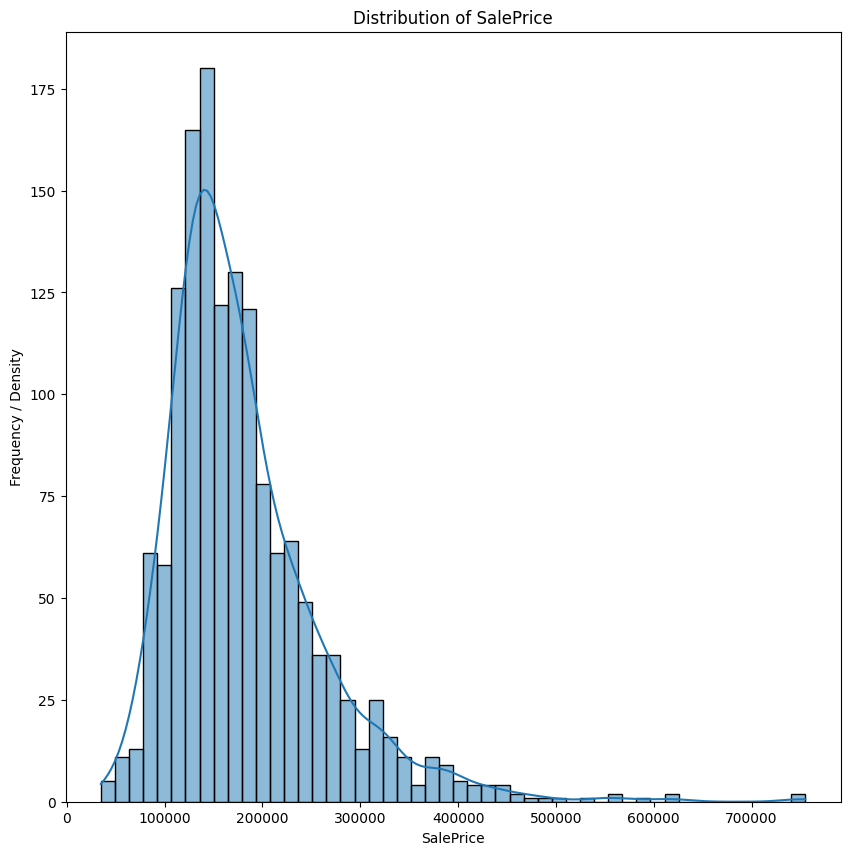

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,10))
sns.histplot(train["SalePrice"], bins=50, kde=True)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency / Density')
plt.show()

In [ ]:
import numpy as np

train["SalePrice"] = np.log1p(
    train["SalePrice"]
)

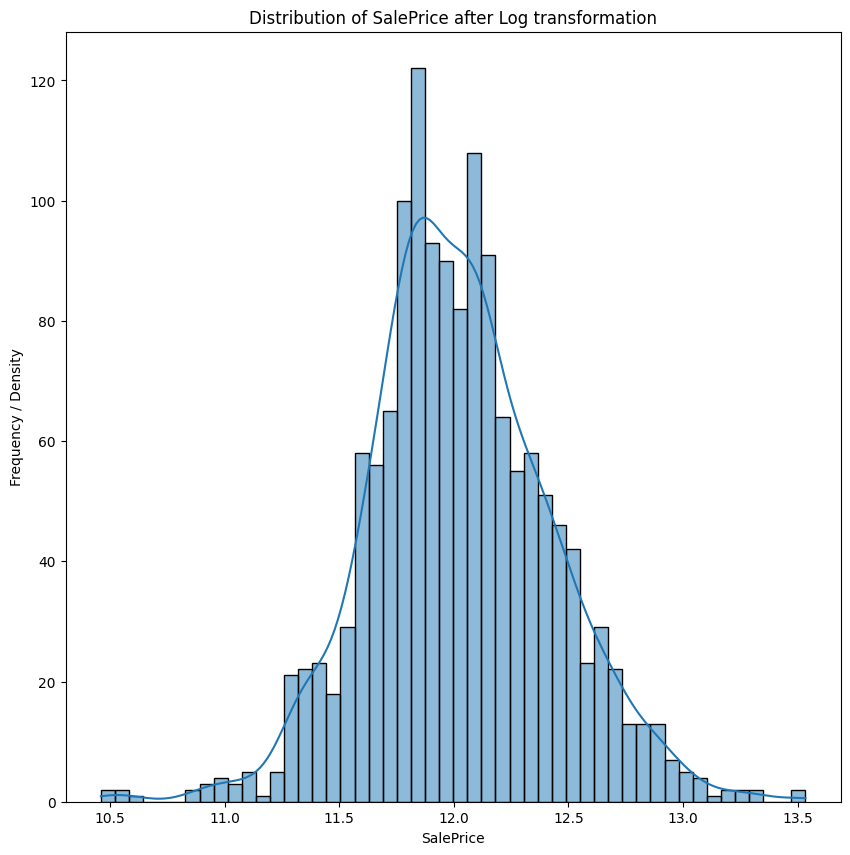

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,10))
sns.histplot(train["SalePrice"], bins=50, kde=True)
plt.title('Distribution of SalePrice after Log transformation')
plt.xlabel('SalePrice')
plt.ylabel('Frequency / Density')
plt.show()

In [ ]:
corr = train.corr(
    numeric_only=True
)

print(
corr["SalePrice"]
.sort_values(
ascending=False
).head(15)
)

SalePrice       1.000000
OverallQual     0.817185
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
FullBath        0.594771
YearBuilt       0.586570
YearRemodAdd    0.565608
GarageYrBlt     0.541073
TotRmsAbvGrd    0.534422
Fireplaces      0.489450
MasVnrArea      0.430809
BsmtFinSF1      0.372023
Name: SalePrice, dtype: float64


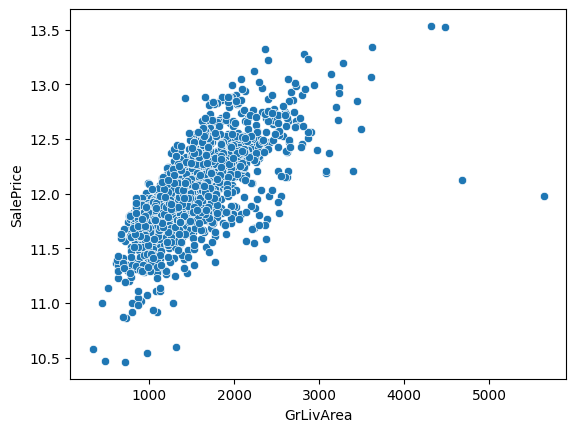

In [ ]:
import seaborn as sns

sns.scatterplot(
x=train["GrLivArea"],
y=train["SalePrice"]
)

plt.show()

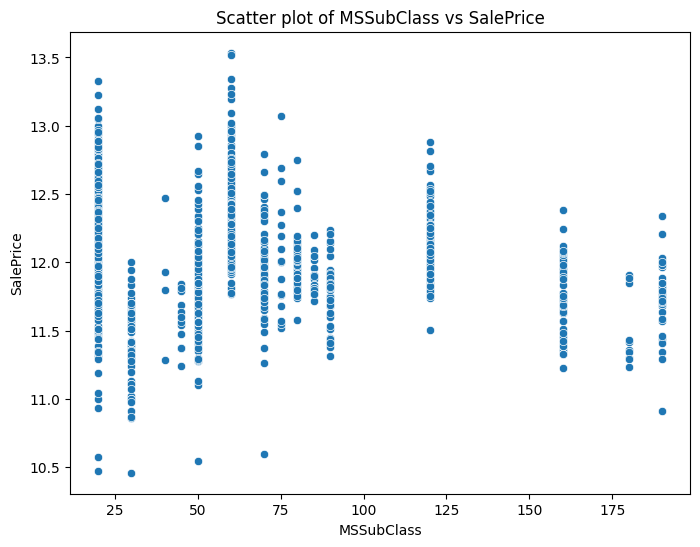

Skipping scatter plot for non-numeric column: MSZoning


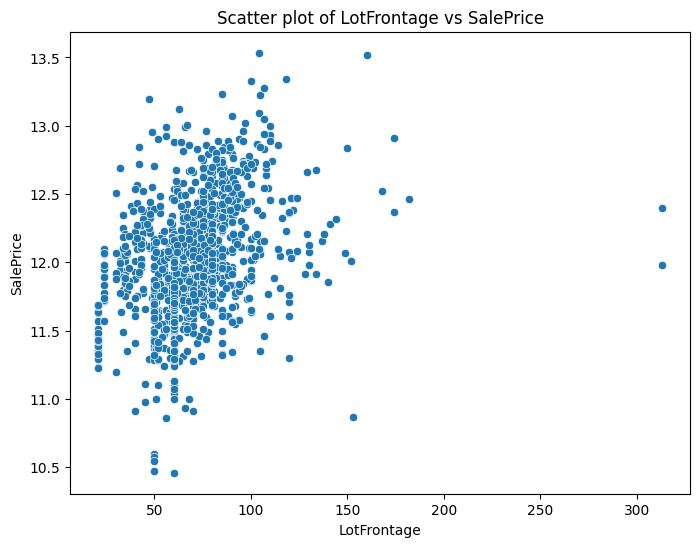

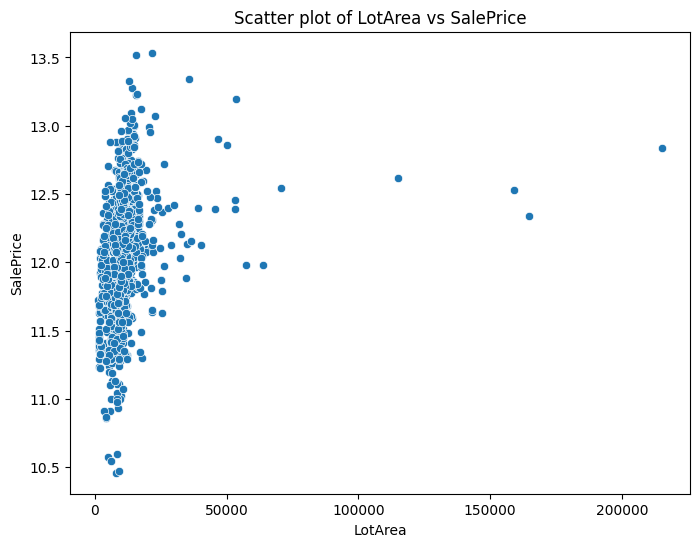

Skipping scatter plot for non-numeric column: Street
Skipping scatter plot for non-numeric column: Alley
Skipping scatter plot for non-numeric column: LotShape
Skipping scatter plot for non-numeric column: LandContour
Skipping scatter plot for non-numeric column: Utilities
Skipping scatter plot for non-numeric column: LotConfig
Skipping scatter plot for non-numeric column: LandSlope
Skipping scatter plot for non-numeric column: Neighborhood
Skipping scatter plot for non-numeric column: Condition1
Skipping scatter plot for non-numeric column: Condition2
Skipping scatter plot for non-numeric column: BldgType
Skipping scatter plot for non-numeric column: HouseStyle


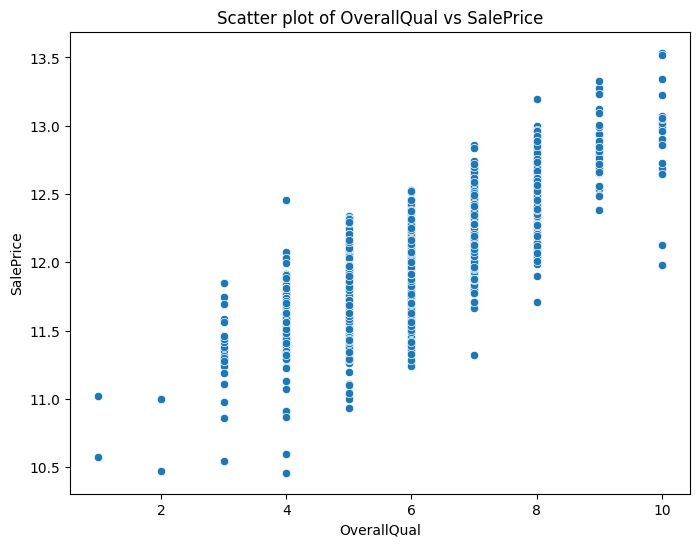

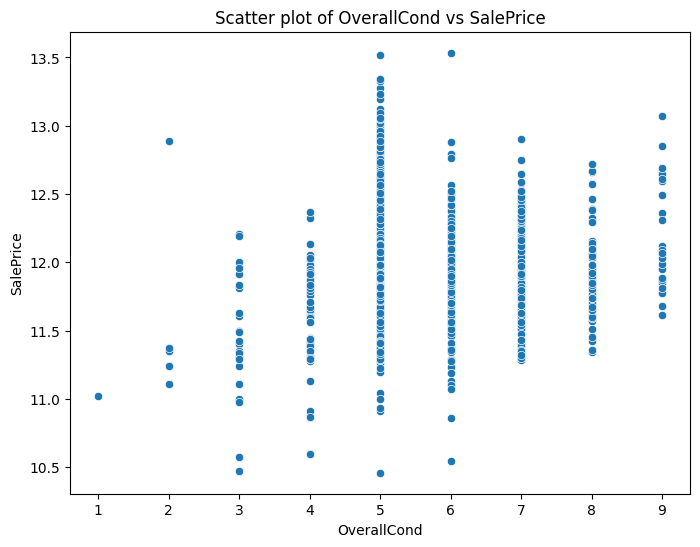

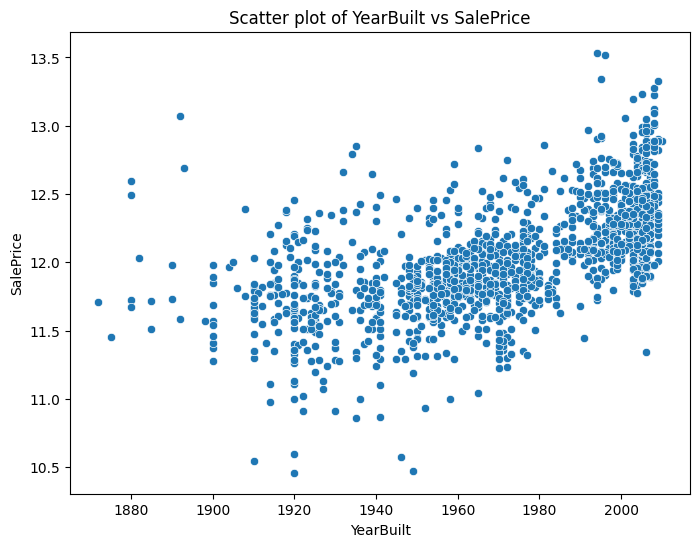

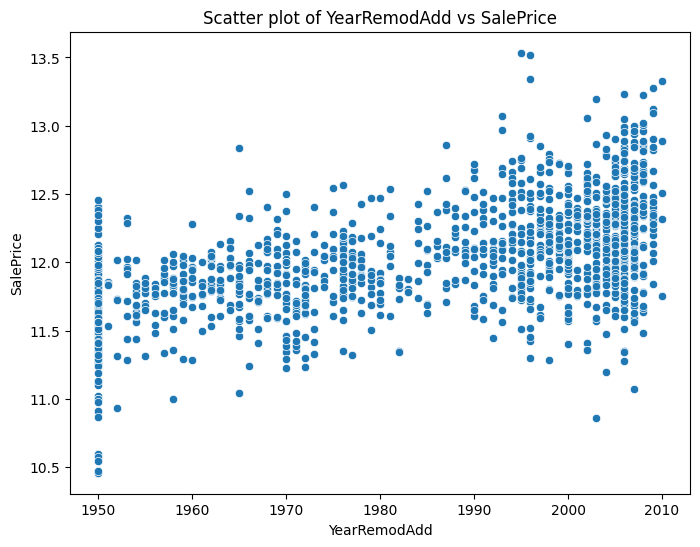

Skipping scatter plot for non-numeric column: RoofStyle
Skipping scatter plot for non-numeric column: RoofMatl
Skipping scatter plot for non-numeric column: Exterior1st
Skipping scatter plot for non-numeric column: Exterior2nd
Skipping scatter plot for non-numeric column: MasVnrType


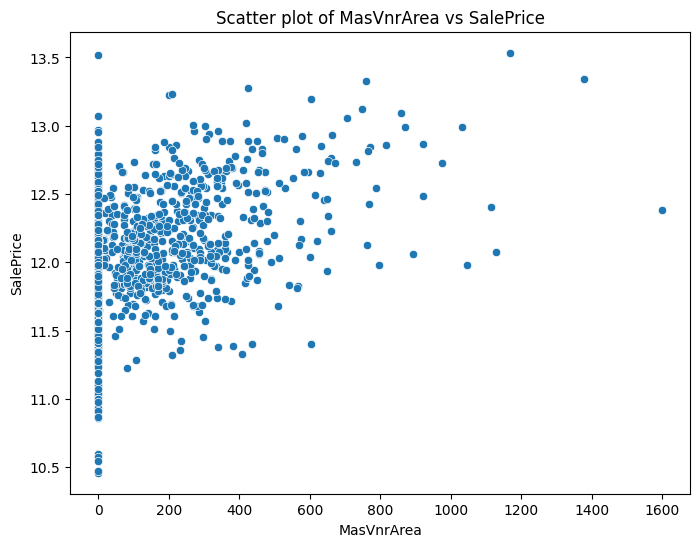

Skipping scatter plot for non-numeric column: ExterQual
Skipping scatter plot for non-numeric column: ExterCond
Skipping scatter plot for non-numeric column: Foundation
Skipping scatter plot for non-numeric column: BsmtQual
Skipping scatter plot for non-numeric column: BsmtCond
Skipping scatter plot for non-numeric column: BsmtExposure
Skipping scatter plot for non-numeric column: BsmtFinType1


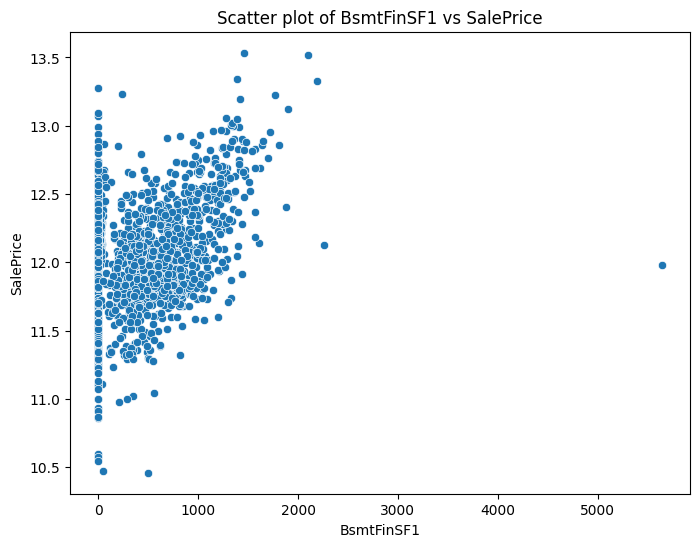

Skipping scatter plot for non-numeric column: BsmtFinType2


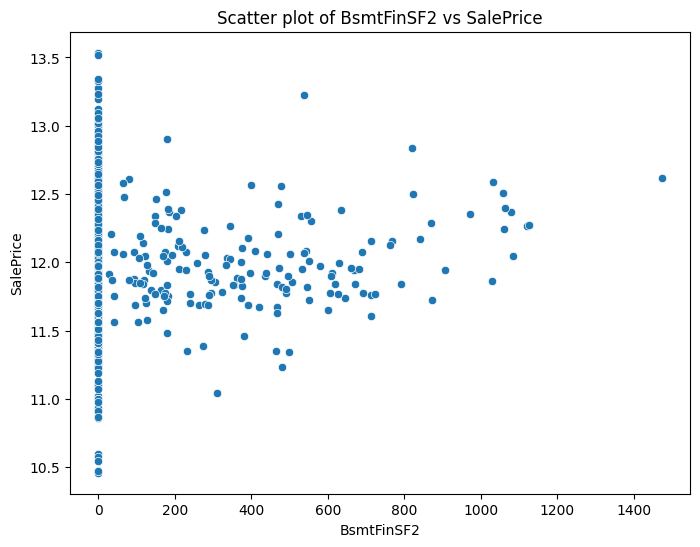

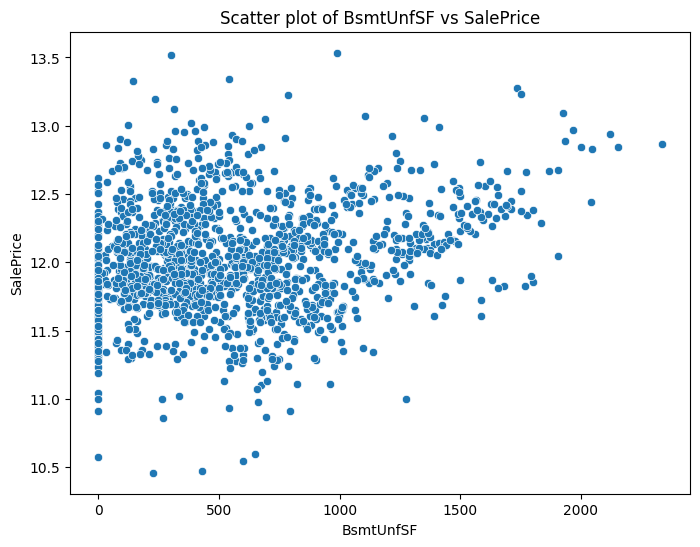

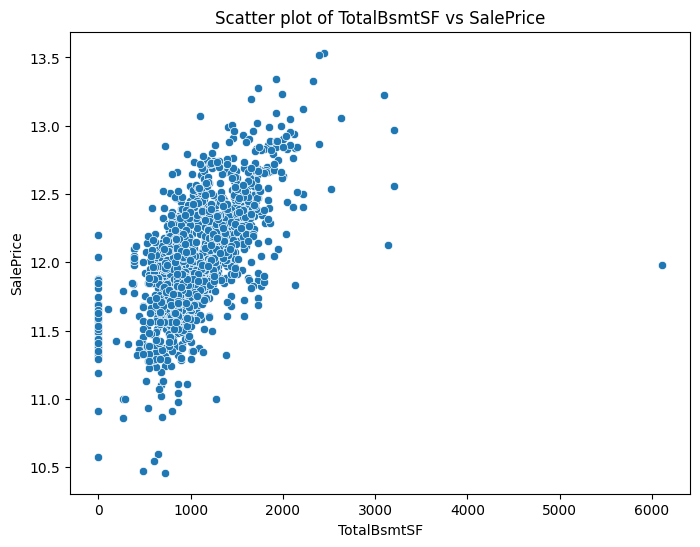

Skipping scatter plot for non-numeric column: Heating
Skipping scatter plot for non-numeric column: HeatingQC
Skipping scatter plot for non-numeric column: CentralAir
Skipping scatter plot for non-numeric column: Electrical


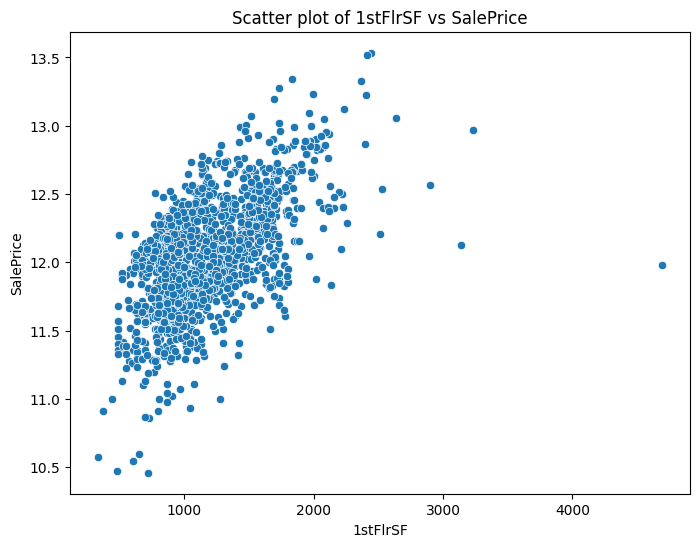

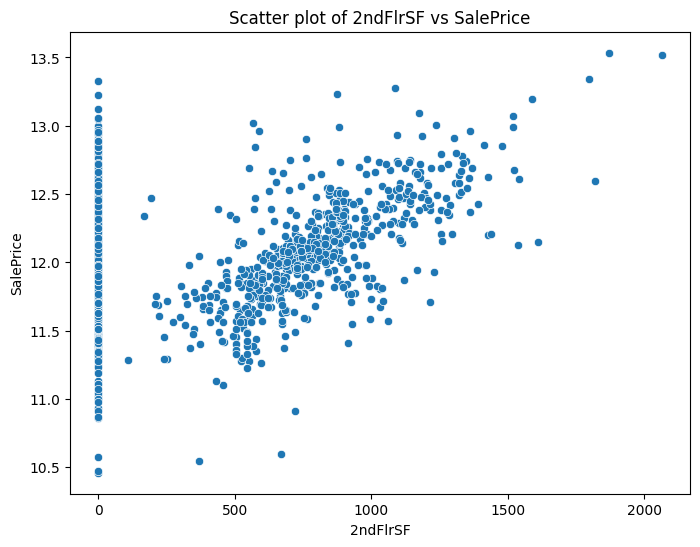

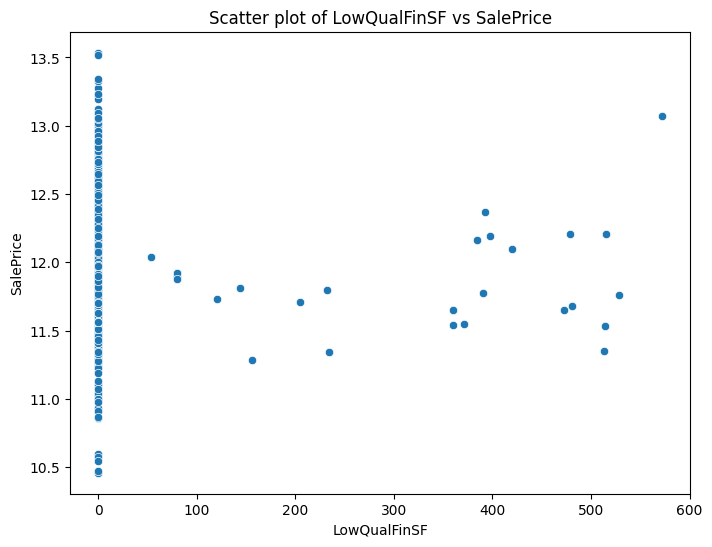

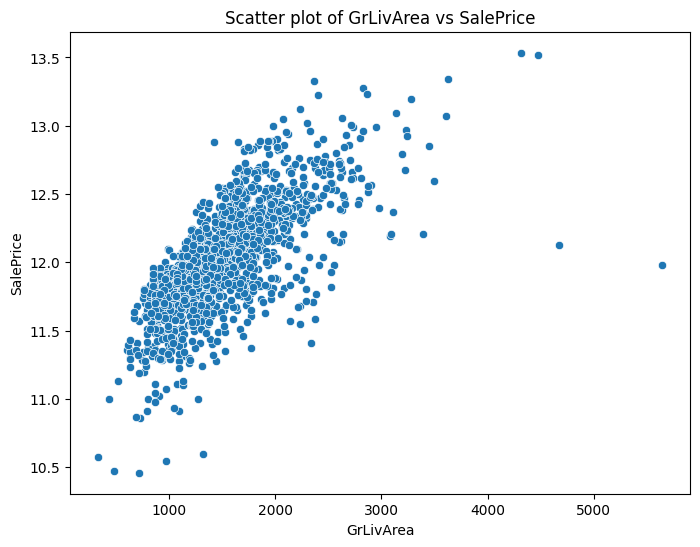

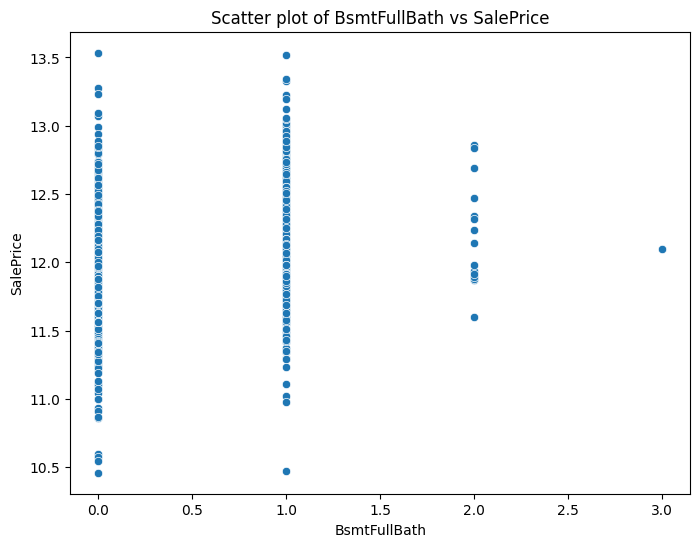

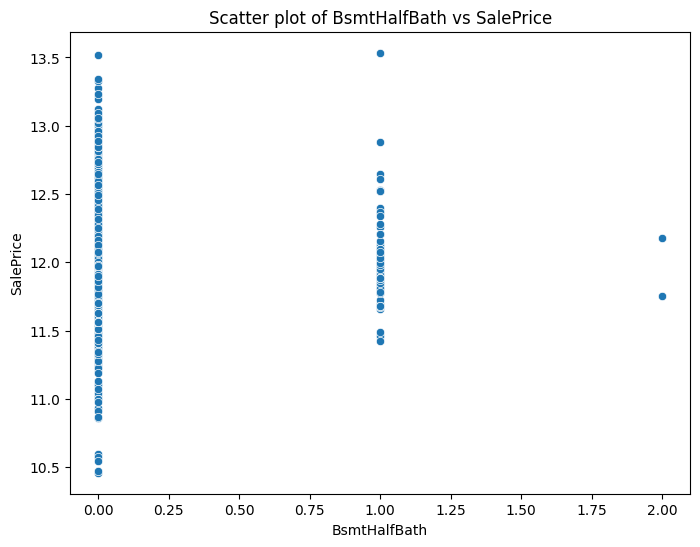

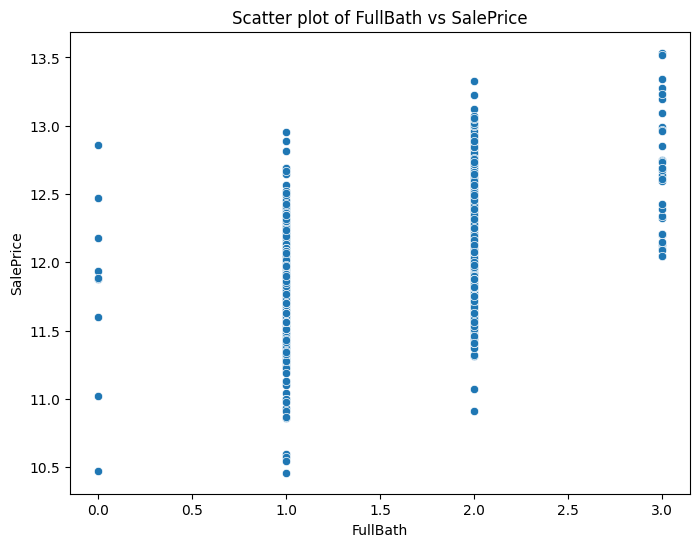

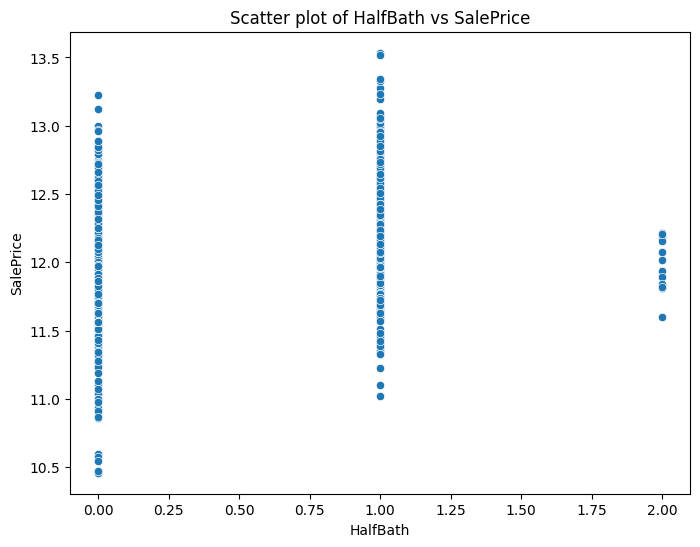

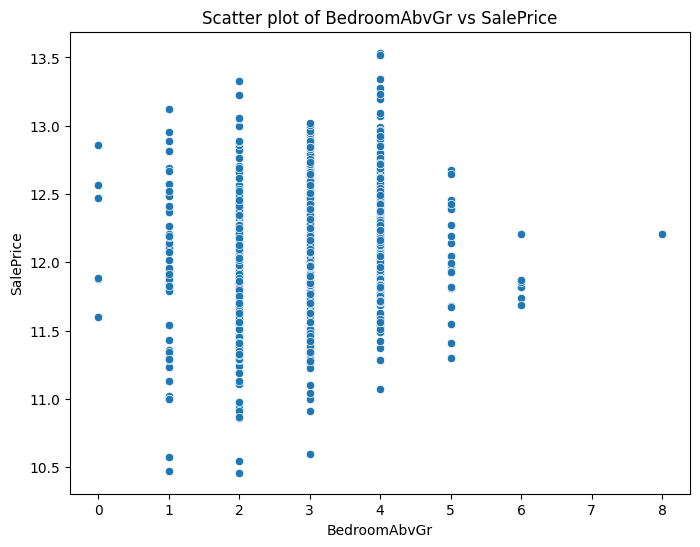

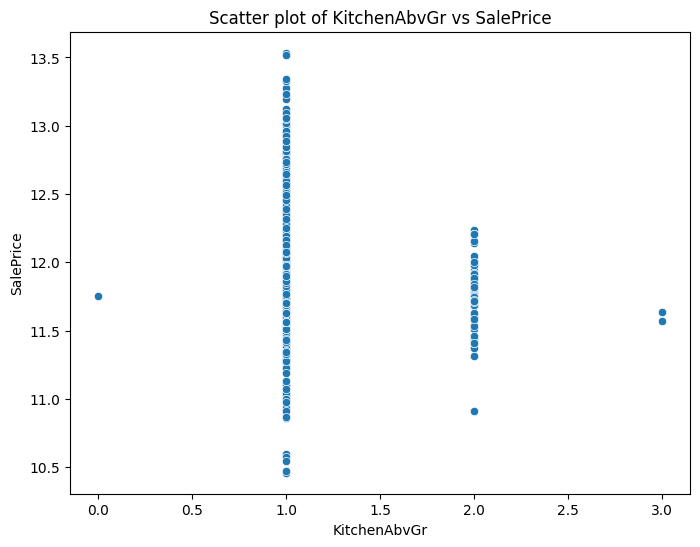

Skipping scatter plot for non-numeric column: KitchenQual


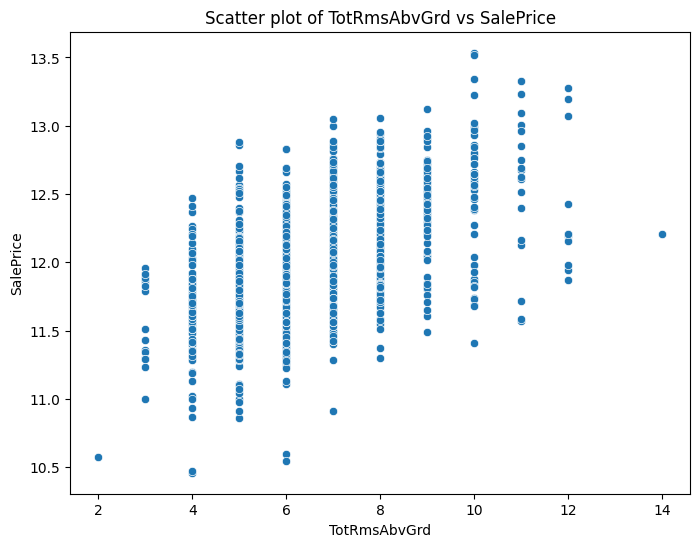

Skipping scatter plot for non-numeric column: Functional


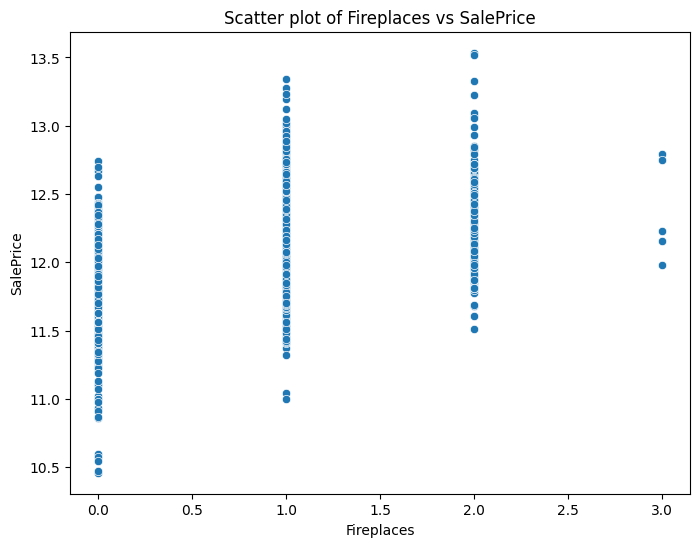

Skipping scatter plot for non-numeric column: FireplaceQu
Skipping scatter plot for non-numeric column: GarageType


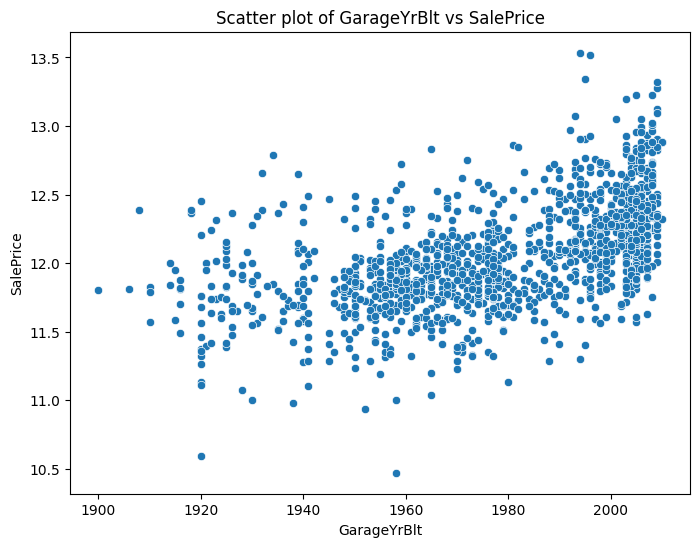

Skipping scatter plot for non-numeric column: GarageFinish


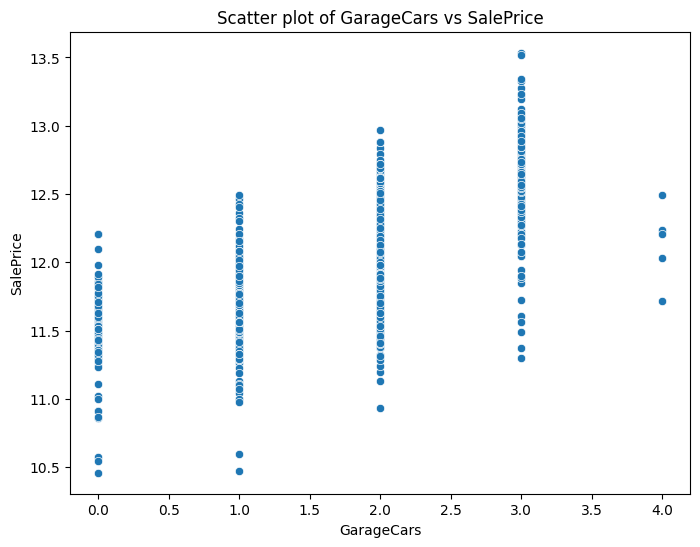

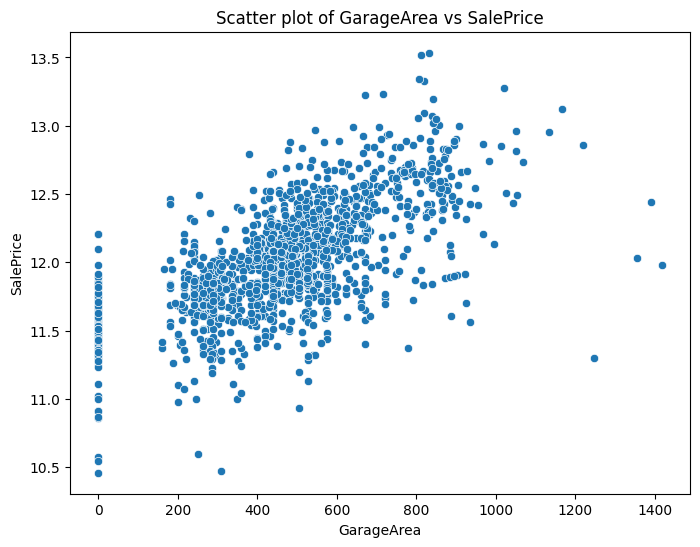

Skipping scatter plot for non-numeric column: GarageQual
Skipping scatter plot for non-numeric column: GarageCond
Skipping scatter plot for non-numeric column: PavedDrive


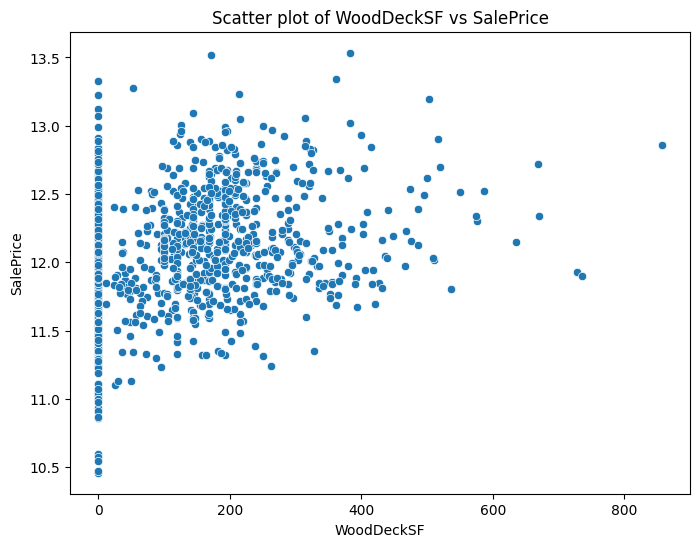

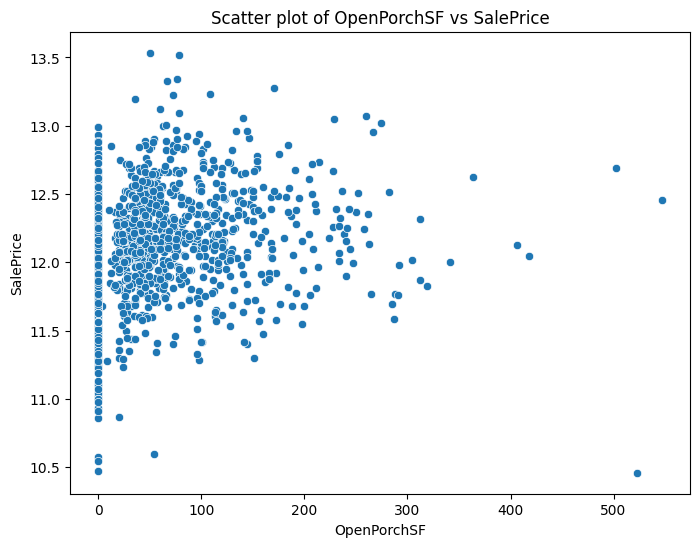

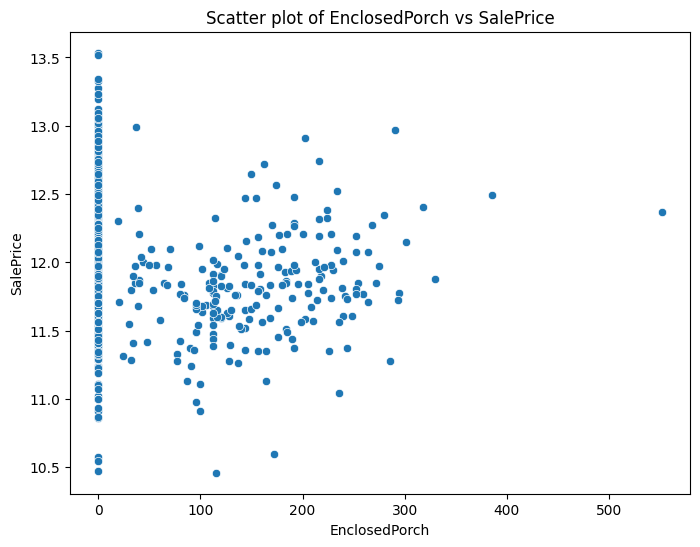

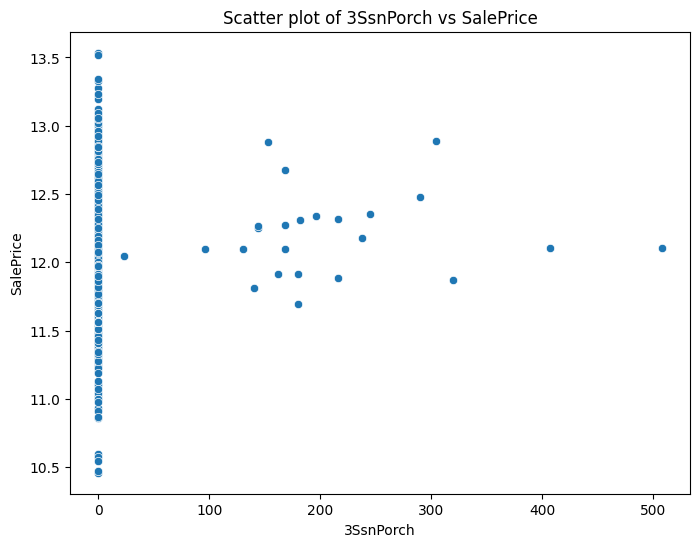

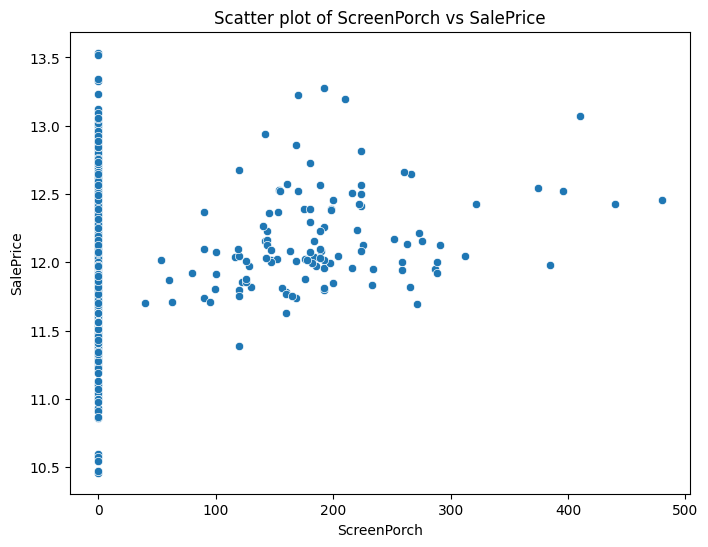

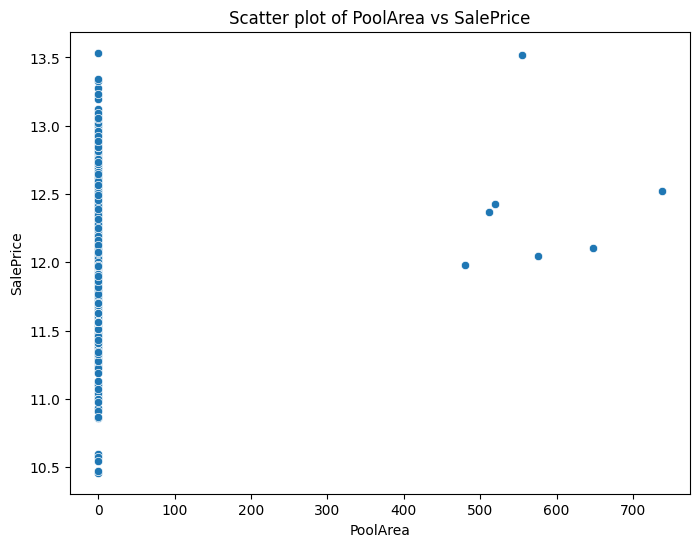

Skipping scatter plot for non-numeric column: PoolQC
Skipping scatter plot for non-numeric column: Fence
Skipping scatter plot for non-numeric column: MiscFeature


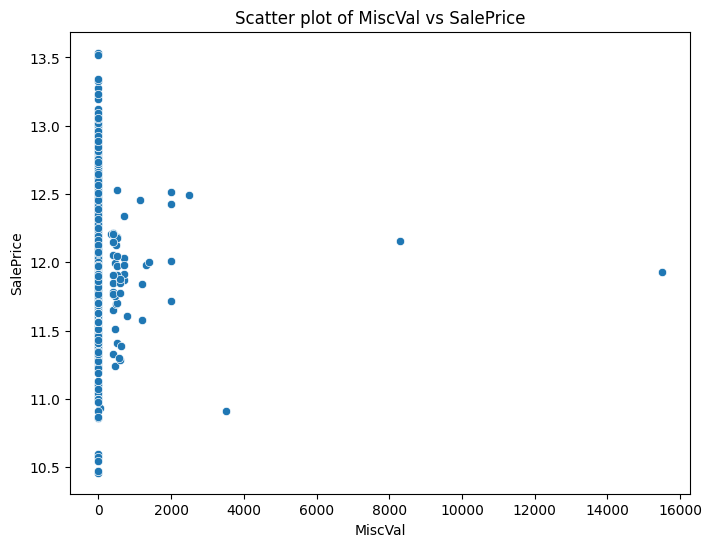

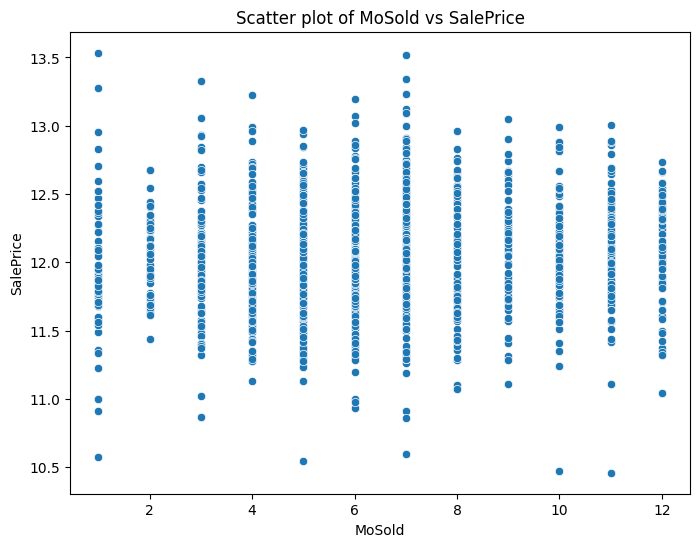

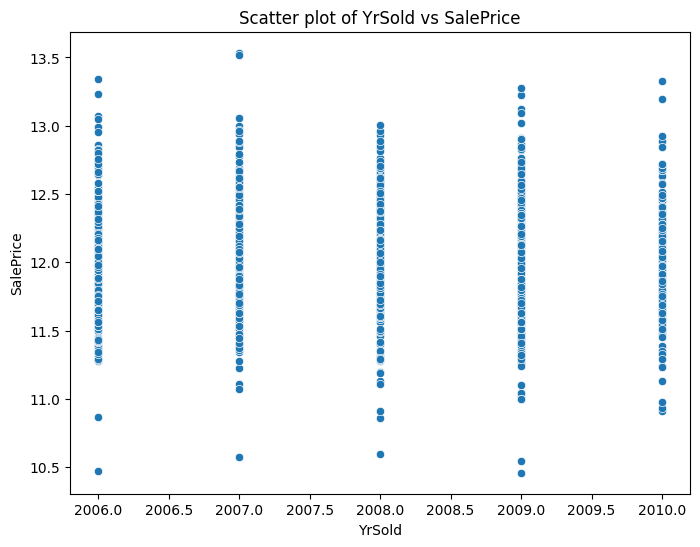

Skipping scatter plot for non-numeric column: SaleType
Skipping scatter plot for non-numeric column: SaleCondition


In [ ]:
import matplotlib.pyplot as plt


for col in train.columns:
    # Skip 'Id' and 'SalePrice' columns for scatter plots against SalePrice
    if col == 'Id' or col == 'SalePrice':
        continue

    # Check if the column is numeric before plotting a scatter plot
    if pd.api.types.is_numeric_dtype(train[col]):
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            x=train[col],
            y=train["SalePrice"]
        )
        plt.title(f'Scatter plot of {col} vs SalePrice')
        plt.xlabel(col)
        plt.ylabel('SalePrice')
        plt.show()
    else:
        # Optionally, you could handle non-numeric columns differently or print a message.
        print(f"Skipping scatter plot for non-numeric column: {col}")

In [ ]:
train.groupby(
    "Neighborhood"
)["SalePrice"].mean().sort_values()

,SalePrice
Neighborhood,
IDOTRR,11.446901
MeadowV,11.474533
BrDale,11.547874
BrkSide,11.679736
OldTown,11.703873
Edwards,11.712321
Sawyer,11.811475
Blueste,11.826543
SWISU,11.838442


In [ ]:
df['Neighborhood']

,Neighborhood
0,CollgCr
1,Veenker
2,CollgCr
3,Crawfor
4,NoRidge
...,...
1454,MeadowV
1455,MeadowV
1456,Mitchel
1457,Mitchel


In [ ]:
train["TotalSF"] = (
train["1stFlrSF"]
+
train["2ndFlrSF"]
+
train["TotalBsmtSF"]
)

In [ ]:
df.shape

(2919, 81)

In [ ]:
skew = train.skew(
numeric_only=True
).sort_values()
skew

,0
GarageYrBlt,-0.649415
YearBuilt,-0.613461
YearRemodAdd,-0.503562
GarageCars,-0.342549
Id,0.000000
FullBath,0.036562
YrSold,0.096269
SalePrice,0.121347
GarageArea,0.179981
BedroomAbvGr,0.211790


In [ ]:
skew_list = skew.values.tolist()

In [ ]:
count = 0
for i in skew_list:
  if -0.5<i<0.5:
    count = count+1
  else:
    pass

print("total symmetic columns: ",count)

total symmetic columns:  9


In [ ]:
missing_ratio = train.isnull().mean()

drop_cols = (
    missing_ratio[
        missing_ratio > 0.80
    ].index
)

train = train.drop(
    columns=drop_cols
)

In [ ]:
for col in train.columns:

    if pd.api.types.is_numeric_dtype(
        train[col]
    ):

        if train[col].isnull().sum() > 0:

            skew = (
                train[col]
                .dropna()
                .skew()
            )

            if abs(skew) > 1:

                train[col] = (
                    train[col]
                    .fillna(
                        train[col]
                        .median()
                    )
                )

            else:

                train[col] = (
                    train[col]
                    .fillna(
                        train[col]
                        .mean()
                    )
                )

    # Categorical columns
    else:

        if train[col].isnull().sum() > 0:

            train[col] = (
                train[col]
                .fillna(
                    train[col]
                    .mode()[0]
                )
            )

In [ ]:
print(
"Remaining NaNs:",
train.isnull().sum().sum()
)

print(
"Final Shape:",
train.shape
)

Remaining NaNs: 0
Final Shape: (1460, 78)


In [ ]:
num_cols = train.select_dtypes(include=["int64", "float64"]).columns

In [ ]:
num_cols

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice', 'TotalSF'],
      dtype='object')

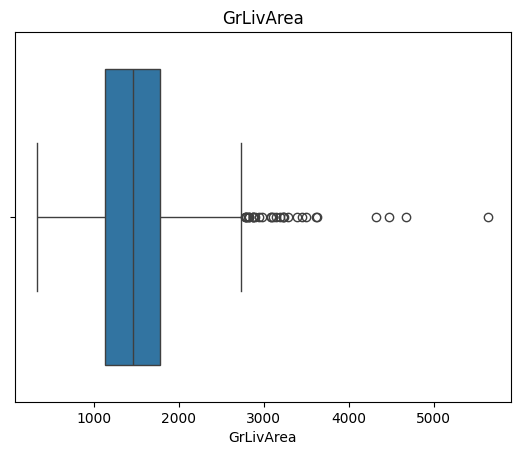

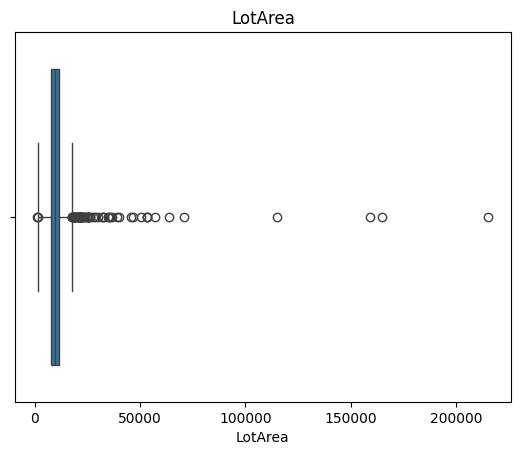

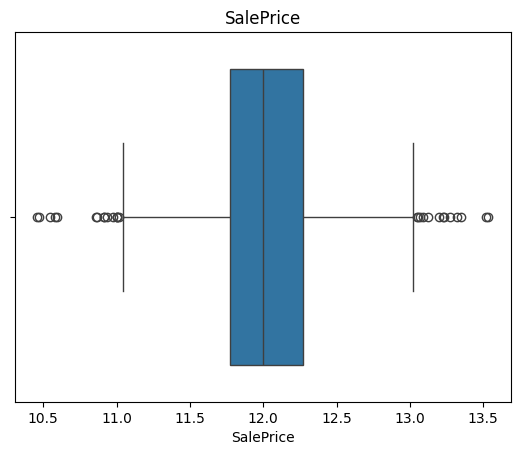

In [ ]:
for col in [
    "GrLivArea",
    "LotArea",
    "SalePrice"
]:

    sns.boxplot(
        x=train[col]
    )

    plt.title(
        col
    )

    plt.show()

In [ ]:
Q1 = train["GrLivArea"].quantile(0.25)
Q3 = train["GrLivArea"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlair = train[(train['GrLivArea'] < lower_bound) | (train['GrLivArea'] > upper_bound)]
print(len(outlair))

31


In [ ]:
len(outlair)/len(train)*100

2.1232876712328768

In [ ]:
y = train["SalePrice"]
X = train.drop(columns=["SalePrice"])

In [ ]:
X = pd.get_dummies(X)

test = pd.get_dummies(test)

X, test = X.align(
    test,
    join="left",
    axis=1,
    fill_value=0
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

In [ ]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001159 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3689
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 175
[LightGBM] [Info] Start training from score 12.030658


LGBMRegressor(learning_rate=0.03, n_estimators=500, random_state=42)

In [ ]:
from sklearn.metrics import (
    mean_squared_error
)

pred = model.predict(
    X_val
)

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        pred
    )
)

print(
    "RMSE:",
    rmse
)

RMSE: 0.13767937762313573


In [ ]:
from sklearn.model_selection import cross_val_score

score = (-cross_val_score(model,X,y,cv=5,scoring="neg_root_mean_squared_error"))

print(score.mean())

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001668 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3674
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 178
[LightGBM] [Info] Start training from score 12.021409
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001659 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3684
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 174
[LightGBM] [Info] Start training from score 12.023288
[LightGBM] [Warning] Found

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


In [ ]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

lgb = LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.01,
    num_leaves=20,
    random_state=42
)

xgb = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.01,
    max_depth=3,
    random_state=42
)

cat = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.01,
    verbose=0
)

lgb.fit(
    X_train,
    y_train
)

xgb.fit(
    X_train,
    y_train
)

cat.fit(
    X_train,
    y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001770 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3689
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 175
[LightGBM] [Info] Start training from score 12.030658


CatBoostRegressor(iterations=1500, learning_rate=0.01, loss_function='RMSE', verbose=0)

In [ ]:
pred_lgb = lgb.predict(X_val)

pred_xgb = xgb.predict(X_val)

pred_cat = cat.predict(X_val)

In [ ]:
pred = (
    0.4 * pred_lgb
    +
    0.3 * pred_xgb
    +
    0.3 * pred_cat
)

In [ ]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        pred
    )
)

print(
    "Ensemble RMSE:",
    rmse
)

Ensemble RMSE: 0.13064655827166444


In [ ]:
test_id = test["Id"]

test_pred = (
0.4*lgb.predict(test)
+
0.3*xgb.predict(test)
+
0.3*cat.predict(test)
)

submission = pd.DataFrame({

"Id": test_id,

"SalePrice":
np.expm1(
test_pred
)

})

submission.to_csv(
"submission.csv",
index=False
)